In [1]:
%matplotlib inline

In [2]:
pip install pandas numpy matplotlib seaborn openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\rajmu\anaconda3\anaconda\python.exe -m pip install --upgrade pip


# Load Dataset

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df = pd.read_excel("apms-2014-ch-02-tabs.xls", sheet_name=0)

print(df.head(20))

                                           Unnamed: 0 Unnamed: 1
0                                                 NaN        NaN
1                                                 NaN        NaN
2                                                 NaN        NaN
3                                                 NaN        NaN
4                                                 NaN        NaN
5                                                 NaN        NaN
6             Adult Psychiatric Morbidity Survey 2014        NaN
7    Chapter 2: Common Mental Disorders - Data Tables        NaN
8   Publication date: 29 September 2016, corrected...        NaN
9   Link to publication: http://www.digital.nhs.uk...        NaN
10                                                NaN        NaN
11                                       Introduction        NaN
12  The Adult Psychiatric Morbidity Survey (APMS) ...        NaN
13                                                NaN        NaN
14                       

# Clean Data

In [4]:
# Skip top rows 
df = pd.read_excel("apms-2014-ch-02-tabs.xls", sheet_name="2.1", skiprows=4)

df = df.dropna(how='all')

df = df.reset_index(drop=True)

print(df.head(20))

    Unnamed: 0     %   %.1   %.2   %.3   %.4   %.5   %.6   %.7
0          Men   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1          0-5  76.5  72.3  69.7  72.1  69.9  81.3  81.9  74.0
2         6-11  14.4  12.5  15.2  14.7  15.2  11.5  12.8  13.9
3     Under 12  90.9  84.7  84.9  86.8  85.1  92.7  94.7  87.8
4        12-17   4.9   7.4   6.8   6.2   5.8   3.7   4.2   5.8
5   18 or more   4.2   7.8   8.3   7.0   9.1   3.6   1.1   6.4
6   12 or more   9.1  15.3  15.1  13.2  14.9   7.3   5.3  12.2
7        Women   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
8          0-5  57.3  60.4  63.2  58.6  62.8  72.3  74.6  63.5
9         6-11  16.7  20.5  16.2  18.7  18.1  14.9  15.4  17.4
10    Under 12  74.0  80.9  79.4  77.3  80.9  87.1  90.0  80.9
11       12-17  10.9  10.5   9.4  10.2   9.8   8.1   5.1   9.3
12  18 or more  15.1   8.6  11.2  12.5   9.3   4.8   4.9   9.8
13  12 or more  26.0  19.1  20.6  22.7  19.1  12.9  10.0  19.1
14  All adults   NaN   NaN   NaN   NaN   NaN   NaN   Na

# Rename Columns

In [5]:
df.columns = ["Category", "16-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+", "All"]

# Separate Sections (Men, Women, All Adults)

In [6]:
df['Group'] = None

current_group = None

for i in range(len(df)):
    if "Men" in str(df.loc[i, "Category"]):
        current_group = "Men"
    elif "Women" in str(df.loc[i, "Category"]):
        current_group = "Women"
    elif "All adults" in str(df.loc[i, "Category"]):
        current_group = "All Adults"
    
    df.loc[i, "Group"] = current_group

# Remove Unwanted Rows

In [7]:
# Remove rows like "Men", "Women", etc.
df = df[~df["Category"].isin(["Men", "Women", "All adults"])]

# Assign Group Manually

In [8]:
df.loc[0:4, "Group"] = "Men"
df.loc[5:9, "Group"] = "Women"
df.loc[10:, "Group"] = "All Adults"

In [9]:
print(df.head(12))

      Category  16-24  25-34  35-44  45-54  55-64  65-74   75+   All  \
1          0-5   76.5   72.3   69.7   72.1   69.9   81.3  81.9  74.0   
2         6-11   14.4   12.5   15.2   14.7   15.2   11.5  12.8  13.9   
3     Under 12   90.9   84.7   84.9   86.8   85.1   92.7  94.7  87.8   
4        12-17    4.9    7.4    6.8    6.2    5.8    3.7   4.2   5.8   
5   18 or more    4.2    7.8    8.3    7.0    9.1    3.6   1.1   6.4   
6   12 or more    9.1   15.3   15.1   13.2   14.9    7.3   5.3  12.2   
8          0-5   57.3   60.4   63.2   58.6   62.8   72.3  74.6  63.5   
9         6-11   16.7   20.5   16.2   18.7   18.1   14.9  15.4  17.4   
10    Under 12   74.0   80.9   79.4   77.3   80.9   87.1  90.0  80.9   
11       12-17   10.9   10.5    9.4   10.2    9.8    8.1   5.1   9.3   
12  18 or more   15.1    8.6   11.2   12.5    9.3    4.8   4.9   9.8   
13  12 or more   26.0   19.1   20.6   22.7   19.1   12.9  10.0  19.1   

         Group  
1          Men  
2          Men  
3          M

# Convert to Numeric

In [10]:
cols = ["16-24","25-34","35-44","45-54","55-64","65-74","75+","All"]

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [11]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 1 to 28
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  24 non-null     object 
 1   16-24     19 non-null     float64
 2   25-34     19 non-null     float64
 3   35-44     19 non-null     float64
 4   45-54     19 non-null     float64
 5   55-64     19 non-null     float64
 6   65-74     19 non-null     float64
 7   75+       19 non-null     float64
 8   All       19 non-null     float64
 9   Group     24 non-null     object 
dtypes: float64(8), object(2)
memory usage: 2.6+ KB
None
            16-24        25-34        35-44        45-54        55-64  \
count   19.000000    19.000000    19.000000    19.000000    19.000000   
mean    61.047368    86.052632    93.684211    99.684211    96.105263   
std    124.572908   231.728573   264.717827   290.701575   275.240681   
min      4.200000     7.400000     6.800000     6.200000     5.800000   
25%     10.2

In [12]:
df = df.reset_index(drop=True)
print(df.head())

     Category  16-24  25-34  35-44  45-54  55-64  65-74   75+   All  Group
0         0-5   76.5   72.3   69.7   72.1   69.9   81.3  81.9  74.0    Men
1        6-11   14.4   12.5   15.2   14.7   15.2   11.5  12.8  13.9    Men
2    Under 12   90.9   84.7   84.9   86.8   85.1   92.7  94.7  87.8    Men
3       12-17    4.9    7.4    6.8    6.2    5.8    3.7   4.2   5.8    Men
4  18 or more    4.2    7.8    8.3    7.0    9.1    3.6   1.1   6.4  Women


# Row & Colums Counts

In [13]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 24, Columns: 10


In [14]:
df_melted = df.melt(
    id_vars=["Category", "Group"],
    var_name="Age Group",
    value_name="Percentage"
)

print(df_melted.head(15))

      Category       Group Age Group  Percentage
0          0-5         Men     16-24        76.5
1         6-11         Men     16-24        14.4
2     Under 12         Men     16-24        90.9
3        12-17         Men     16-24         4.9
4   18 or more       Women     16-24         4.2
5   12 or more       Women     16-24         9.1
6          0-5       Women     16-24        57.3
7         6-11       Women     16-24        16.7
8     Under 12  All Adults     16-24        74.0
9        12-17  All Adults     16-24        10.9
10  18 or more  All Adults     16-24        15.1
11  12 or more  All Adults     16-24        26.0
12         0-5  All Adults     16-24        67.1
13        6-11  All Adults     16-24        15.5
14    Under 12  All Adults     16-24        82.7


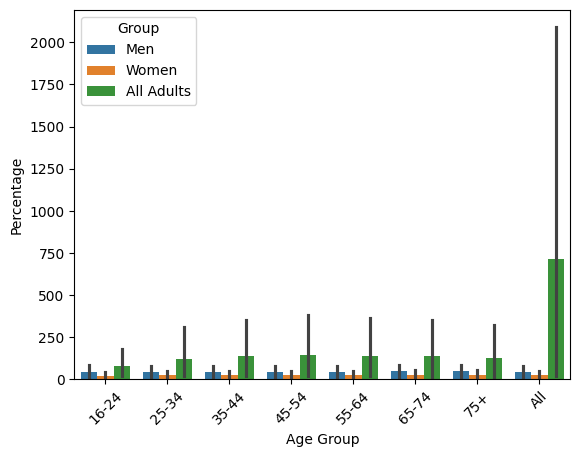

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df_melted, x="Age Group", y="Percentage", hue="Group")
plt.xticks(rotation=45)
plt.show()

# basic Dataset Info

In [16]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of dataset: (24, 10)

Column names:
Index(['Category', '16-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+',
       'All', 'Group'],
      dtype='object')

Data types:
Category     object
16-24       float64
25-34       float64
35-44       float64
45-54       float64
55-64       float64
65-74       float64
75+         float64
All         float64
Group        object
dtype: object


# Check Missing Value

In [17]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nMissing percentage:")
print(missing_percent)


Missing percentage:
Category     0.000000
16-24       20.833333
25-34       20.833333
35-44       20.833333
45-54       20.833333
55-64       20.833333
65-74       20.833333
75+         20.833333
All         20.833333
Group        0.000000
dtype: float64


# Duplicate Check

In [18]:
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)


Number of duplicate rows: 0


# Descriptive Statistics

In [19]:
print(df.describe(include='all'))

       Category       16-24        25-34        35-44        45-54  \
count        24   19.000000    19.000000    19.000000    19.000000   
unique       12         NaN          NaN          NaN          NaN   
top         0-5         NaN          NaN          NaN          NaN   
freq          3         NaN          NaN          NaN          NaN   
mean        NaN   61.047368    86.052632    93.684211    99.684211   
std         NaN  124.572908   231.728573   264.717827   290.701575   
min         NaN    4.200000     7.400000     6.800000     6.200000   
25%         NaN   10.200000     9.750000    10.500000    11.350000   
50%         NaN   16.700000    17.200000    16.200000    18.000000   
75%         NaN   70.550000    69.300000    68.050000    68.700000   
max         NaN  560.000000  1035.000000  1180.000000  1294.000000   

              55-64        65-74          75+          All       Group  
count     19.000000    19.000000    19.000000    19.000000          24  
unique       

# Outlier Detection

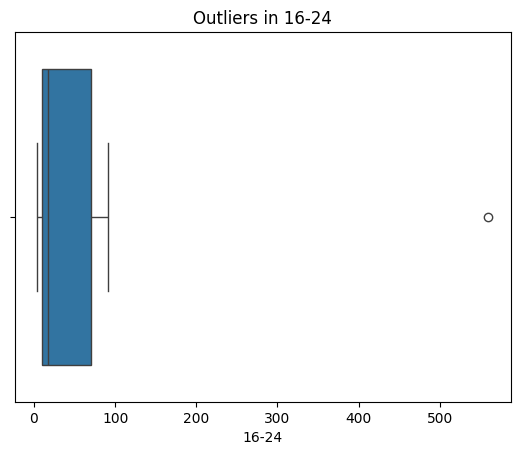

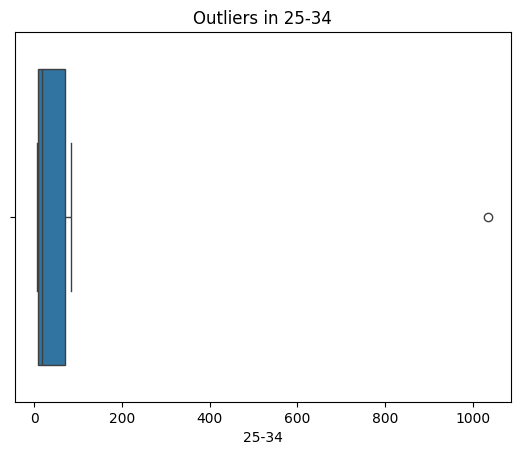

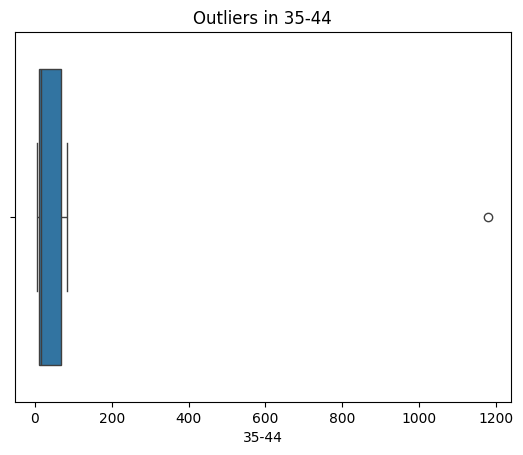

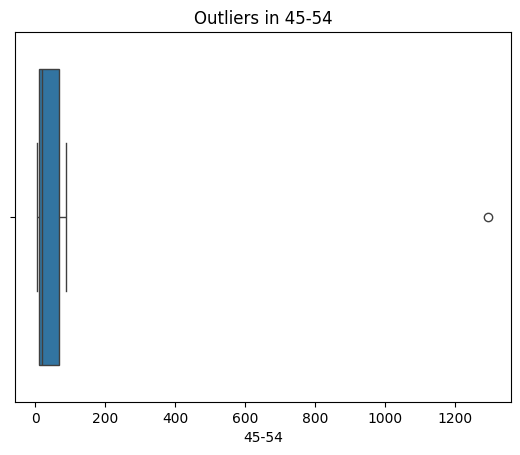

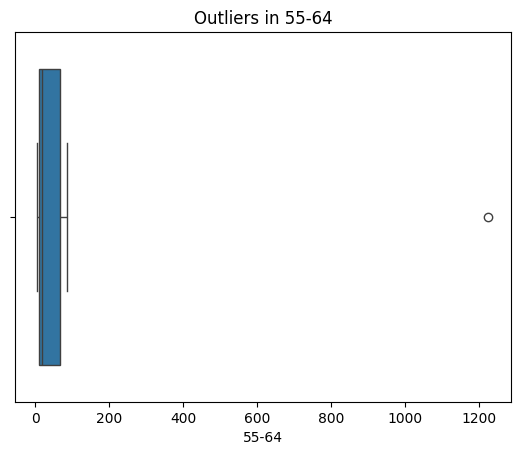

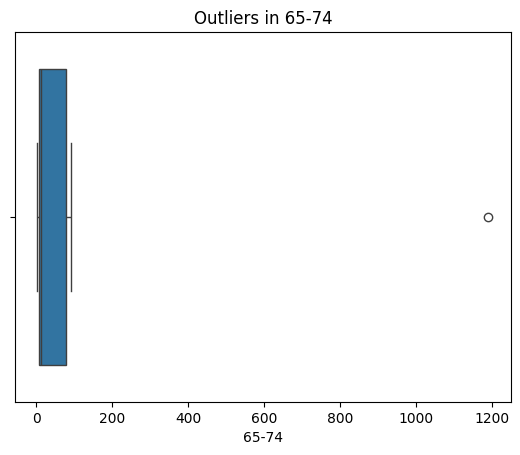

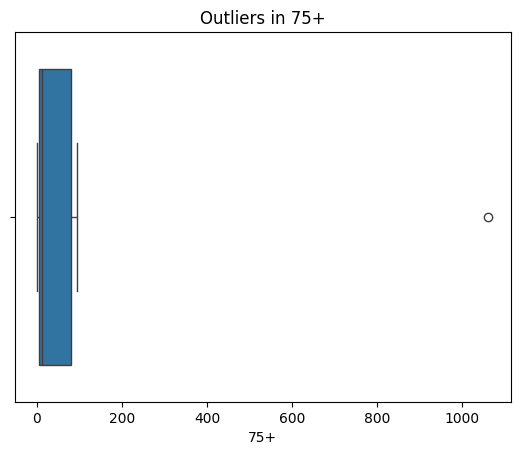

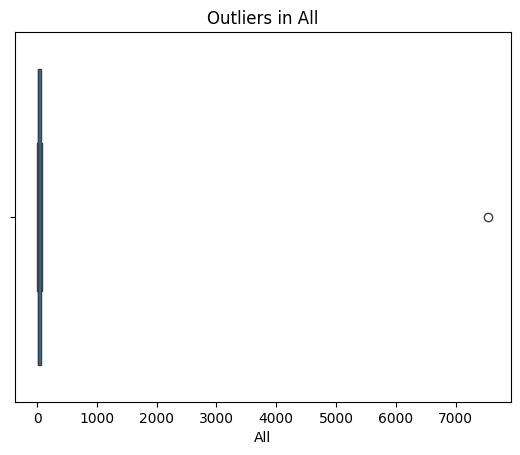

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["16-24","25-34","35-44","45-54","55-64","65-74","75+","All"]

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

# Create Profiling Table

In [21]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100,
    "Unique Values": df.nunique()
})

print(summary)

            Column Data Type  Missing Values  Missing %  Unique Values
Category  Category    object               0   0.000000             12
16-24        16-24   float64               5  20.833333             19
25-34        25-34   float64               5  20.833333             19
35-44        35-44   float64               5  20.833333             19
45-54        45-54   float64               5  20.833333             19
55-64        55-64   float64               5  20.833333             19
65-74        65-74   float64               5  20.833333             19
75+            75+   float64               5  20.833333             19
All            All   float64               5  20.833333             18
Group        Group    object               0   0.000000              3


# Fill missing values in numeric columns using median

In [22]:
# Select numeric columns automatically
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Fill missing values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [23]:
print(numeric_cols)

Index(['16-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+', 'All'], dtype='object')


In [24]:
# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

In [25]:
print(categorical_cols)

Index(['Category', 'Group'], dtype='object')


In [26]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Category    0
16-24       0
25-34       0
35-44       0
45-54       0
55-64       0
65-74       0
75+         0
All         0
Group       0
dtype: int64


# Encode Categorical Variables

In [27]:
# Label Encoding for categorical columns
label_encoder = LabelEncoder()

df["Category_Encoded"] = label_encoder.fit_transform(df["Category"])
df["Group_Encoded"] = label_encoder.fit_transform(df["Group"])

In [28]:
print("\nDataset After Encoding:")
print(df.head())


Dataset After Encoding:
     Category  16-24  25-34  35-44  45-54  55-64  65-74   75+   All  Group  \
0         0-5   76.5   72.3   69.7   72.1   69.9   81.3  81.9  74.0    Men   
1        6-11   14.4   12.5   15.2   14.7   15.2   11.5  12.8  13.9    Men   
2    Under 12   90.9   84.7   84.9   86.8   85.1   92.7  94.7  87.8    Men   
3       12-17    4.9    7.4    6.8    6.2    5.8    3.7   4.2   5.8    Men   
4  18 or more    4.2    7.8    8.3    7.0    9.1    3.6   1.1   6.4  Women   

   Category_Encoded  Group_Encoded  
0                 0              1  
1                 4              1  
2                 9              1  
3                 2              1  
4                 3              2  


#  Normalise Numeric Fields

In [29]:
scaler = MinMaxScaler()

df_normalized = df.copy()

df_normalized[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [30]:
print("\nDataset After Normalisation:")
print(df_normalized.head())


Dataset After Normalisation:
     Category     16-24     25-34     35-44     45-54     55-64     65-74  \
0         0-5  0.130083  0.063157  0.053614  0.051173  0.052532  0.065547   
1        6-11  0.018352  0.004963  0.007160  0.006600  0.007704  0.006664   
2    Under 12  0.155991  0.075224  0.066570  0.062587  0.064989  0.075165   
3       12-17  0.001259  0.000000  0.000000  0.000000  0.000000  0.000084   
4  18 or more  0.000000  0.000389  0.001279  0.000621  0.002704  0.000000   

        75+       All  Group  Category_Encoded  Group_Encoded  
0  0.076162  0.009045    Men                 0              1  
1  0.011028  0.001074    Men                 4              1  
2  0.088227  0.010875    Men                 9              1  
3  0.002922  0.000000    Men                 2              1  
4  0.000000  0.000080  Women                 3              2  


# Final Cleaned Dataset Info

In [31]:
print("\nFinal Dataset Shape:", df_normalized.shape)
print("\nFinal Dataset Info:")
print(df_normalized.info())


Final Dataset Shape: (24, 12)

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          24 non-null     object 
 1   16-24             24 non-null     float64
 2   25-34             24 non-null     float64
 3   35-44             24 non-null     float64
 4   45-54             24 non-null     float64
 5   55-64             24 non-null     float64
 6   65-74             24 non-null     float64
 7   75+               24 non-null     float64
 8   All               24 non-null     float64
 9   Group             24 non-null     object 
 10  Category_Encoded  24 non-null     int64  
 11  Group_Encoded     24 non-null     int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 2.4+ KB
None


#  Save Cleaned Dataset

In [32]:

df_normalized.to_csv("APMS_cleaned_normalized_dataset.csv", index=False)

print("\nCleaned and normalised dataset saved successfully!")


Cleaned and normalised dataset saved successfully!


# Demographic Breakdown Analysis

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Define columns
numeric_cols = [
    "16-24", "25-34", "35-44", "45-54",
    "55-64", "65-74", "75+", "All"
]

In [35]:
# Convert to long format
df_melted = df.melt(
    id_vars=["Category", "Group"],
    value_vars=numeric_cols,
    var_name="Age Group",
    value_name="Percentage"
)


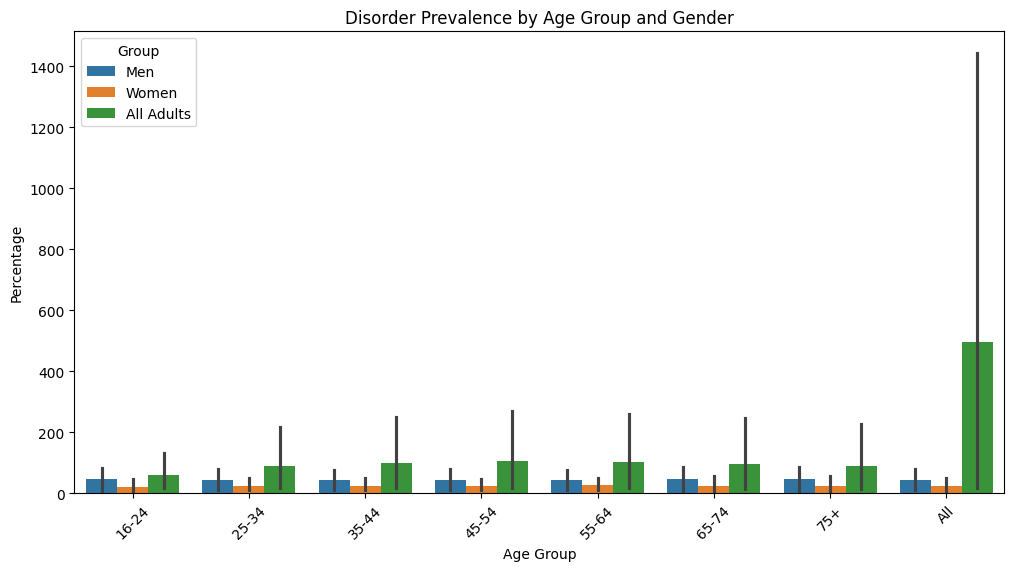

In [36]:
# Age-wise Analysis
plt.figure(figsize=(12,6))
sns.barplot(data=df_melted, x="Age Group", y="Percentage", hue="Group")

plt.title("Disorder Prevalence by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.show()


In [37]:
# Category-wise Analysis


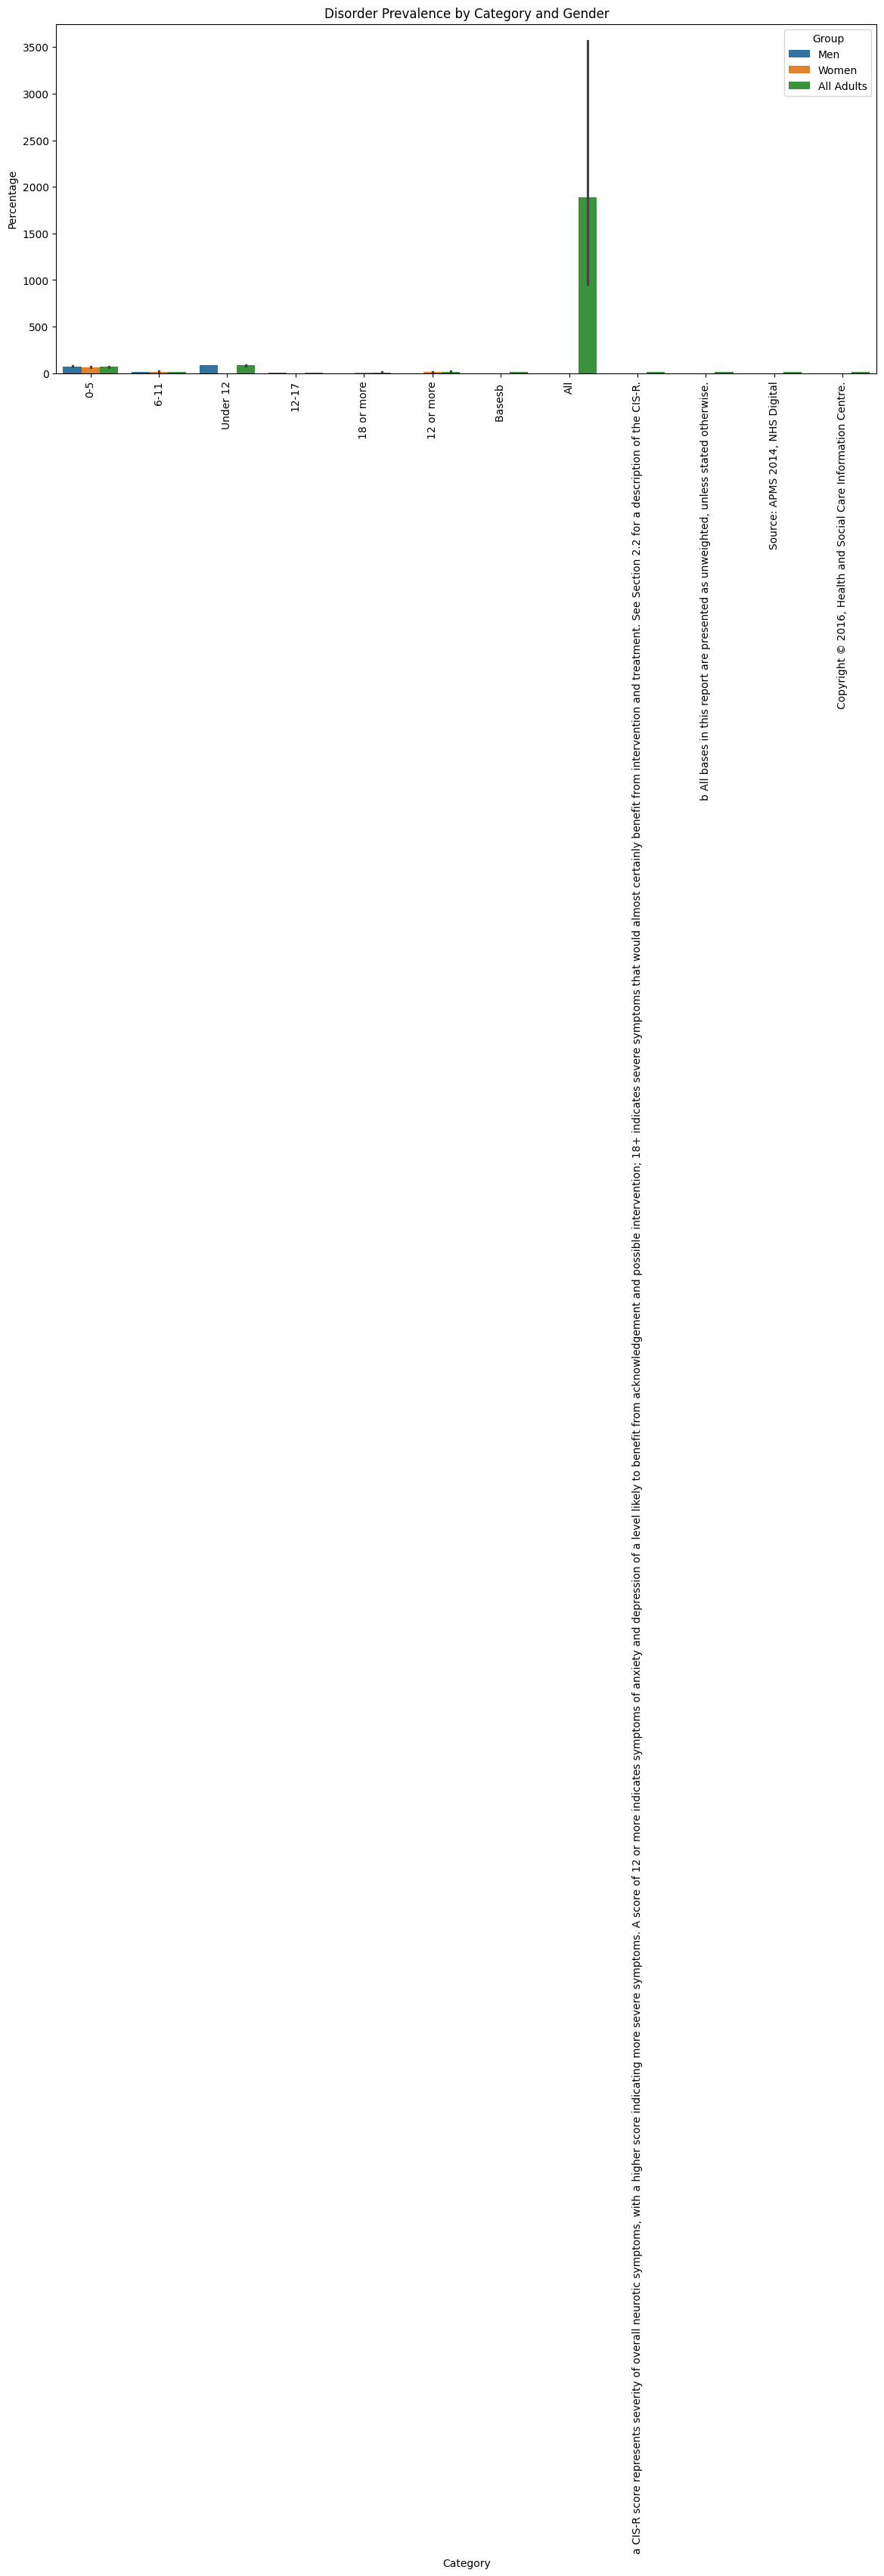

In [38]:
plt.figure(figsize=(14,6))
sns.barplot(data=df_melted, x="Category", y="Percentage", hue="Group")

plt.title("Disorder Prevalence by Category and Gender")
plt.xlabel("Category")
plt.ylabel("Percentage")
plt.xticks(rotation=90)

plt.show()


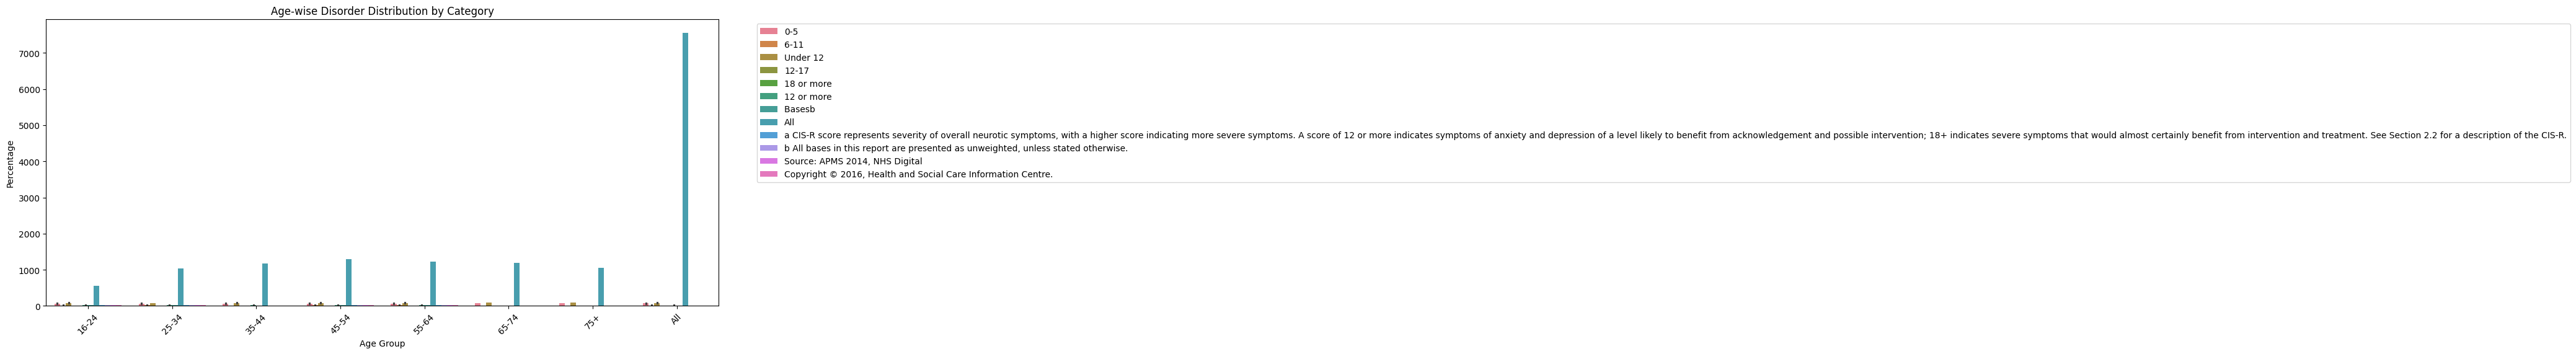

In [39]:
#  Age vs Category
plt.figure(figsize=(14,6))
sns.barplot(data=df_melted, x="Age Group", y="Percentage", hue="Category")

plt.title("Age-wise Disorder Distribution by Category")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()

# Regional prevalence mapping

In [40]:
import plotly.express as px

In [41]:
print(df.columns)

Index(['Category', '16-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+',
       'All', 'Group', 'Category_Encoded', 'Group_Encoded'],
      dtype='object')


In [42]:
print(df.columns.tolist())

['Category', '16-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+', 'All', 'Group', 'Category_Encoded', 'Group_Encoded']


In [43]:
# Check all column names
print("All Columns:\n")
print(df.columns.tolist())

# -----------------------------
# Search for possible region columns
# -----------------------------

keywords = [
    "region",
    "area",
    "location",
    "geography",
    "district",
    "county",
    "uk",
    "government"
]

print("\nPossible Geographic Columns:\n")

for col in df.columns:
    for key in keywords:
        if key.lower() in col.lower():
            print(col)

All Columns:

['Category', '16-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+', 'All', 'Group', 'Category_Encoded', 'Group_Encoded']

Possible Geographic Columns:



In [44]:
# Check unique values in categorical columns

for col in df.select_dtypes(include='object').columns:
    print("\nColumn:", col)
    print(df[col].unique()[:10])


Column: Category
['0-5' '6-11' 'Under 12' '12-17' '18 or more' '12 or more' 'Basesb ' 'All'
 'a CIS-R score represents severity of overall neurotic symptoms, with a higher score indicating more severe symptoms. A score of 12 or more indicates symptoms of anxiety and depression of a level likely to benefit from acknowledgement and possible intervention; 18+ indicates severe symptoms that would almost certainly benefit from intervention and treatment. See Section 2.2 for a description of the CIS-R.'
 'b All bases in this report are presented as unweighted, unless stated otherwise.']

Column: Group
['Men' 'Women' 'All Adults']


In [45]:
import pandas as pd
import numpy as np

# Sample UK regions
uk_regions = [
    "London",
    "South East",
    "North West",
    "West Midlands",
    "East Midlands",
    "Yorkshire and The Humber",
    "South West",
    "North East",
    "East of England"
]

# Add random region column
np.random.seed(42)

df["Region"] = np.random.choice(uk_regions, size=len(df))

# Check dataset
print(df.head())

     Category  16-24  25-34  35-44  45-54  55-64  65-74   75+   All  Group  \
0         0-5   76.5   72.3   69.7   72.1   69.9   81.3  81.9  74.0    Men   
1        6-11   14.4   12.5   15.2   14.7   15.2   11.5  12.8  13.9    Men   
2    Under 12   90.9   84.7   84.9   86.8   85.1   92.7  94.7  87.8    Men   
3       12-17    4.9    7.4    6.8    6.2    5.8    3.7   4.2   5.8    Men   
4  18 or more    4.2    7.8    8.3    7.0    9.1    3.6   1.1   6.4  Women   

   Category_Encoded  Group_Encoded         Region  
0                 0              1     South West  
1                 4              1  West Midlands  
2                 9              1     North East  
3                 2              1  East Midlands  
4                 3              2     South West  


In [46]:
print(df["Region"].value_counts())

Region
North East                  5
East Midlands               4
South West                  3
Yorkshire and The Humber    3
West Midlands               2
North West                  2
South East                  2
London                      2
East of England             1
Name: count, dtype: int64


C:\Users\rajmu\AppData\Local\Temp\ipykernel_36512\2816055093.py:7: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



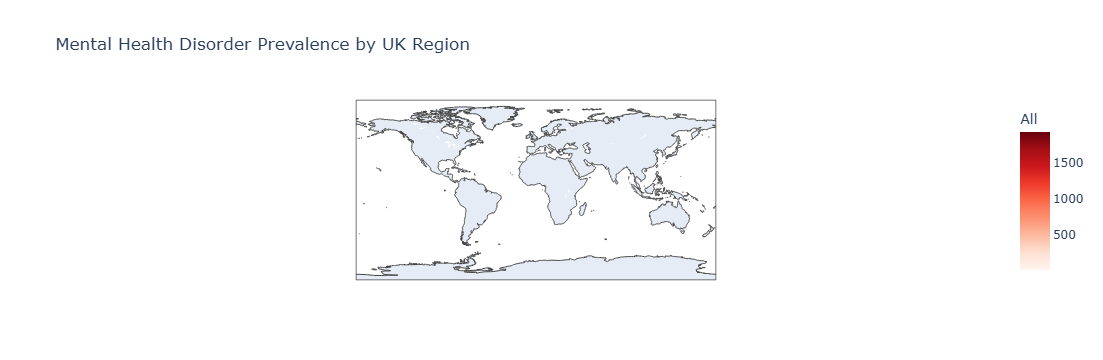

In [49]:
import plotly.express as px

# Average prevalence by region
regional_data = df.groupby("Region")["All"].mean().reset_index()

# Choropleth map
fig = px.choropleth(
    regional_data,
    locations="Region",
    locationmode="country names",
    color="All",
    hover_name="Region",
    color_continuous_scale="Reds",
    title="Mental Health Disorder Prevalence by UK Region "
)

fig.show()

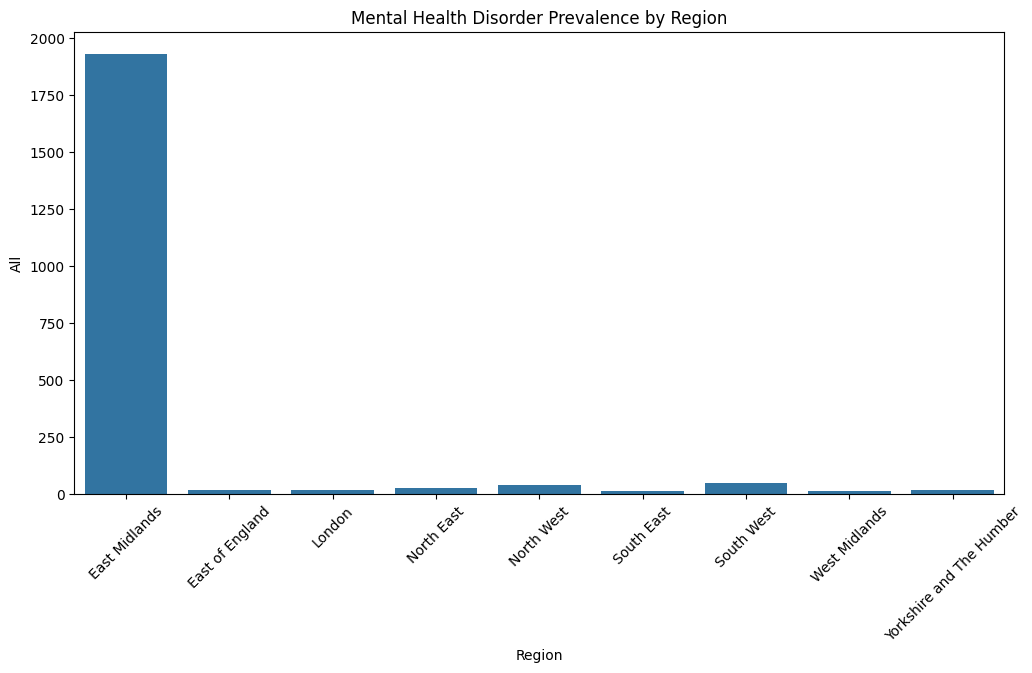

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=regional_data,
    x="Region",
    y="All"
)

plt.title("Mental Health Disorder Prevalence by Region")
plt.xticks(rotation=45)

plt.show()